# Evaluating Splice Usage Predictions by Trajectory Type

For each species/tissue, developmental splice-site trajectories have been clustered by
**shape** and annotated with a `ClusterShape` label (see
[splice_trajectory_clustering.ipynb](splice_trajectory_clustering.ipynb)):
`up_early`, `up_late`, `down_early`, `flat_high`, `up-down`, ... .

This notebook joins those annotated clusters to **model predictions** and asks:

> *How well does the model recover each type of developmental trajectory?*

## Pipeline
1. **Load usage predictions** — per (site, condition) true & predicted SSE from `usage_{species}.npz`.
2. **Trajectory correlations** — Pearson r / MAE / cosine per site × tissue
   (same definition as the *Calculate trajectory correlations* section of `splice_model_eval.ipynb`).
3. **Attach cluster annotations** — join each site × tissue to its `ClusterShape`.
4. **Evaluate by trajectory type** —
   metric distributions, mean true-vs-predicted profile, and example sites per cluster shape.

## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

try:
    from alphagenome_pytorch.plotting.splicing import (
        TISSUE_COLORS, TISSUE_ORDER, SPECIES_SCI,
    )
except Exception:  # keep the notebook usable even without the package
    SPECIES_SCI = {"human": "Homo_sapiens", "mouse": "Mus_musculus",
                   "rat": "Rattus_norvegicus", "rabbit": "Oryctolagus_cuniculus",
                   "opossum": "Monodelphis_domestica"}
    TISSUE_ORDER = ["Brain", "Midbrain", "Cerebellum", "Heart", "Kidney",
                    "Liver", "Ovary", "Testis"]
    TISSUE_COLORS = {}

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
sns.set_style("whitegrid")

In [2]:
# ── Paths / config ────────────────────────────────────────────────────────────
SPECIES   = "human"

# Model predictions (usage_{species}.npz with chr_pos / cond_ids / true / pred)
MODEL = "lora_32_human_mouse_rat_rabbit_opossum"
PRED_ROOT = f"/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/{MODEL}/preds_intersect_protein_coding"
USAGE_NPZ = os.path.join(PRED_ROOT, SPECIES, f"usage_{SPECIES}.npz")

# Condition metadata: condition index -> "Tissue_Timepoint"
ANN_DATA_DIR  = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data"
METADATA_JSON = os.path.join(ANN_DATA_DIR, SPECIES_SCI[SPECIES], "usage.json")

# Annotated trajectory clusters (one row per site x Tissue -> Cluster / ClusterShape).
# The all-tissues clustering is the natural join partner because predictions are
# also per site x tissue x timepoint. Point this at a per-tissue metadata parquet
# (e.g. clustering_usage_human_Brain/human_brain_test_clustering_metadata.parquet)
# to explore a single tissue's clustering instead.
CLUST_DIR = "/home/elek/sds/sd17d003/Anamaria/gp_splice_usage/"
TISSUE = "Brain"
CLUSTER_PARQUET = os.path.join(CLUST_DIR, SPECIES, TISSUE, f"{SPECIES}_{TISSUE}_test_clustering_metadata.parquet")

# Where to write figures / summary tables
OUT_DIR = os.path.join(PRED_ROOT, SPECIES, "trajectory_types")
os.makedirs(OUT_DIR, exist_ok=True)

for p in (USAGE_NPZ, METADATA_JSON, CLUSTER_PARQUET):
    print(("OK  " if os.path.exists(p) else "MISS") + f"  {p}")

OK    /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/usage_human.npz
OK    /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/data/Homo_sapiens/usage.json
OK    /home/elek/sds/sd17d003/Anamaria/gp_splice_usage/human/Brain/human_Brain_test_clustering_metadata.parquet


In [3]:
# Shape taxonomy is shared via alphagenome_pytorch.plotting.splicing
# (same source of truth as scripts/cluster_trajectories.py and
# splice_trajectory_clustering.ipynb).
from alphagenome_pytorch.plotting.splicing import SHAPE_COLORS, SHAPE_ORDER

shape_color = lambda s: SHAPE_COLORS.get(s, "#7f7f7f")

## 1 — Load usage predictions

Load per-(site, condition) true and predicted SSE and split each condition into its
`Tissue` and `Timepoint`.

In [4]:
with open(METADATA_JSON) as f:
    metadata = json.load(f)
idx_to_label = {int(v): k for k, v in metadata.get("condition_labels", {}).items()}

data = np.load(USAGE_NPZ)
chr_pos  = np.asarray(data["chr_pos"]).astype(str)
cond_ids = np.asarray(data["cond_ids"], dtype=int)
trues    = np.asarray(data["true"], dtype=float)
preds    = np.asarray(data["pred"], dtype=float)

tissues    = np.array([idx_to_label[c].rsplit("_", 1)[0] for c in cond_ids])
timepoints = np.array([int(idx_to_label[c].rsplit("_", 1)[1]) for c in cond_ids])

usage_df = pd.DataFrame({
    "chr_pos":    chr_pos,
    "cond_idx":   cond_ids,
    "tissue":     tissues,
    "timepoint":  timepoints,
    "true_usage": trues,
    "pred_usage": preds,
})
usage_df[["chromosome", "position"]] = usage_df["chr_pos"].str.split(":", expand=True)
usage_df["position"] = usage_df["position"].astype(int)

print(f"{len(usage_df):,} observations  |  "
      f"{usage_df['chr_pos'].nunique():,} sites  |  "
      f"{usage_df['tissue'].nunique()} tissues  |  "
      f"{usage_df['timepoint'].nunique()} timepoints")
usage_df.head()

1,305,511 observations  |  19,899 sites  |  8 tissues  |  15 timepoints


,chr_pos,cond_idx,tissue,timepoint,true_usage,pred_usage,chromosome,position
0,1:1535506,0,Brain,1,0.796,0.633890,1,1535506
1,1:1535588,0,Brain,1,0.864,0.630842,1,1535588
2,1:1535796,0,Brain,1,0.714,0.563340,1,1535796
3,1:1539683,0,Brain,1,0.578,0.462847,1,1539683
4,1:1539789,0,Brain,1,0.353,0.440507,1,1539789


## 2 — Trajectory correlations per site × tissue

For every site × tissue we treat the SSE values across timepoints as a trajectory and
score how closely the predicted trajectory matches the true one (Pearson r, MAE, cosine).
This reuses the metric definitions from the *Calculate trajectory correlations* section of
`splice_model_eval.ipynb`.

In [5]:
def _pearson_safe(x, y):
    if len(x) < 2 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def _mean_safe(a):
    a = np.asarray(a, float)
    a = a[np.isfinite(a)]
    return np.mean(a) if len(a) else np.nan

def _traj_metrics(g):
    x = g["true_usage"].to_numpy(float)
    y = g["pred_usage"].to_numpy(float)
    nx, ny = np.linalg.norm(x), np.linalg.norm(y)
    obs = x > 0
    return pd.Series({
        "pearson_r":       _pearson_safe(x, y),
        "mae":             np.sqrt(np.mean((x - y) ** 2)),
        "cosine":          float(np.dot(x, y) / (nx * ny)) if nx > 0 and ny > 0 else np.nan,
        "n_obs_usage":     int(g.loc[obs, "cond_idx"].nunique()),
        "mean_true_usage": _mean_safe(x),
        "mean_pred_usage": _mean_safe(y),
        "max_true_usage":  float(x.max()) if len(x) else np.nan,
        "min_obs_usage":   float(x[obs].min()) if obs.any() else np.nan,
    })

site_corr = (
    usage_df.groupby(["chr_pos", "chromosome", "position", "tissue"], as_index=False)
    .apply(_traj_metrics)
    .reset_index(drop=True)
)

# Drop sites never observed as used (all true == 0) -> undefined trajectory
n_no_obs = site_corr["min_obs_usage"].isna().sum()
print(f"Sites with no observed usage > 0: {n_no_obs:,} / {len(site_corr):,} "
      f"({n_no_obs / len(site_corr):.1%}) — removed")
site_corr = site_corr[site_corr["min_obs_usage"].notna()].reset_index(drop=True)
print(f"{len(site_corr):,} site x tissue trajectories scored")
site_corr.head()

Sites with no observed usage > 0: 26,778 / 159,192 (16.8%) — removed
132,414 site x tissue trajectories scored


/tmp/ipykernel_1873816/1174637460.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_traj_metrics)


,chr_pos,chromosome,position,tissue,pearson_r,mae,cosine,n_obs_usage,mean_true_usage,mean_pred_usage,max_true_usage,min_obs_usage
0,10:100969590,10,100969590,Brain,-0.335032,0.253453,0.988816,6.0,0.941667,0.718907,1.000,0.821
1,10:100969590,10,100969590,Cerebellum,0.759793,0.352916,0.991731,4.0,0.979250,0.634954,1.000,0.958
2,10:100969590,10,100969590,Heart,NaN,0.479923,1.000000,1.0,0.962000,0.482077,0.962,0.962
3,10:100969590,10,100969590,Kidney,-1.000000,0.482628,0.981958,2.0,0.950000,0.481702,1.000,0.900
4,10:100969590,10,100969590,Liver,0.419142,0.383883,0.992431,5.0,0.887800,0.512635,0.947,0.727


## 3 — Attach cluster annotations

Join each scored site × tissue trajectory to its annotated `ClusterShape`.

In [6]:
clusters = pd.read_parquet(CLUSTER_PARQUET)
clusters["chromosome"] = clusters["Chromosome"].astype(str)
clusters["position"]   = clusters["Position"].astype(int)

# The all-tissues clustering carries a Tissue column; per-tissue metadata files do not.
if "Tissue" in clusters.columns:
    clusters["tissue"] = clusters["Tissue"].astype(str)
    join_keys = ["chromosome", "position", "tissue"]
else:
    # Per-tissue clustering file: the clusters were derived from TISSUE alone, so the
    # labels only describe that tissue's developmental trajectories. Restrict to it.
    # Joining on site alone would give every tissue of a site the same label, and a
    # cluster's pattern would be averaged away against tissues where those sites are
    # flat or unexpressed (they also drag in all-zero trajectories).
    join_keys = ["chromosome", "position"]
    n_before  = len(site_corr)
    usage_df  = usage_df[usage_df["tissue"] == TISSUE].reset_index(drop=True)
    site_corr = site_corr[site_corr["tissue"] == TISSUE].reset_index(drop=True)
    print(f"No Tissue column in clustering file — clusters are {TISSUE}-derived, so "
          f"trajectories are restricted to {TISSUE}: {len(site_corr):,} / {n_before:,}")

keep = join_keys + ["Cluster", "ClusterShape", "ClusterMeanSSE", "ClusterRangeSSE"]
traj = site_corr.merge(clusters[keep].drop_duplicates(join_keys),
                       on=join_keys, how="inner")

print(f"Matched {len(traj):,} / {len(site_corr):,} scored trajectories to a cluster "
      f"({len(traj) / len(site_corr):.1%})")
print(f"Tissues in scope: {sorted(traj['tissue'].unique())}")
print(f"Cluster shapes present: {sorted(traj['ClusterShape'].dropna().unique())}")

traj.head()

No Tissue column in clustering file — clusters are Brain-derived, so trajectories are restricted to Brain: 17,852 / 132,414
Matched 15,518 / 17,852 scored trajectories to a cluster (86.9%)
Tissues in scope: ['Brain']
Cluster shapes present: ['complex', 'down-up', 'down_early', 'down_late', 'down_mid', 'flat_high', 'flat_low', 'flat_mid', 'flat_mid_high', 'flat_mid_low', 'up-down', 'up_early', 'up_late', 'up_mid']


,chr_pos,chromosome,position,tissue,pearson_r,mae,cosine,n_obs_usage,mean_true_usage,mean_pred_usage,max_true_usage,min_obs_usage,Cluster,ClusterShape,ClusterMeanSSE,ClusterRangeSSE
0,10:100969590,10,100969590,Brain,-0.335032,0.253453,0.988816,6.0,0.941667,0.718907,1.000,0.821,66,flat_high,0.959920,0.011598
1,10:100969923,10,100969923,Brain,0.385360,0.190635,0.896188,8.0,0.306625,0.199303,0.643,0.074,14,down_mid,0.256480,0.257509
2,10:100972528,10,100972528,Brain,0.814940,0.479018,0.967838,9.0,0.583111,0.162075,1.000,0.100,42,up_early,0.582615,0.433049
3,10:100972893,10,100972893,Brain,-0.324284,0.435477,0.804274,7.0,0.042875,0.462340,0.091,0.028,2,flat_low,0.050345,0.009685
4,10:100973035,10,100973035,Brain,-0.125105,0.257735,0.988474,11.0,0.982909,0.754185,1.000,0.886,67,flat_high,0.970680,0.022229


## 4 — Evaluate by trajectory type

### 4.1 How many trajectories of each type?

In [7]:
# Separate shapes into dynamic and flat
all_shapes = [s for s in SHAPE_ORDER if s in set(traj["ClusterShape"])]
dynamic_shapes = [s for s in all_shapes if not s.startswith("flat")]
flat_shapes = [s for s in all_shapes if s.startswith("flat")]


# Helper plotting function for consistency across figures
def plot_counts(
    categories,
    counts,
    colors,
    title,
    out_filename,
    xlabel="",
    bar_width=0.35,
    rotate_labels=False,
):
    fig, ax = plt.subplots(figsize=(max(6, len(categories) * bar_width), 3.6))
    bars = ax.bar(
        range(len(categories)),
        counts,
        color=colors,
        edgecolor="white",
        lw=0.5,
    )

    max_c = max(counts) if len(counts) > 0 and max(counts) > 0 else 1
    rot_val = 90 if rotate_labels else 0

    for b, c in zip(bars, counts):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + max_c * 0.01,
            f"{c:,}",
            ha="center",
            va="bottom",
            fontsize=8 if not rotate_labels else 7,
            rotation=rot_val,
        )

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(
        categories,
        rotation=90 if rotate_labels else 40,
        ha="right" if not rotate_labels else "center",
        fontsize=8,
    )
    if xlabel:
        ax.set_xlabel(xlabel)
    ax.set_ylabel("# site x tissue trajectories")
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(
        os.path.join(OUT_DIR, out_filename), dpi=200, bbox_inches="tight"
    )
    plt.show()

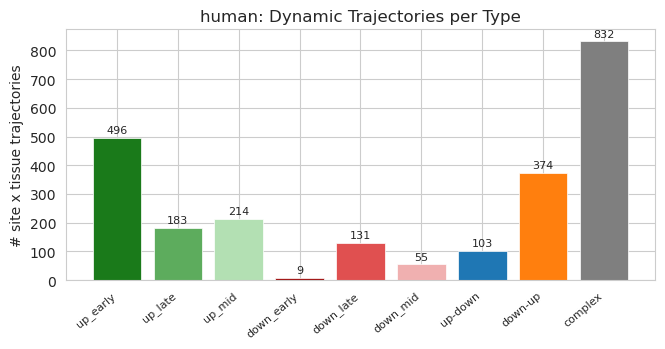

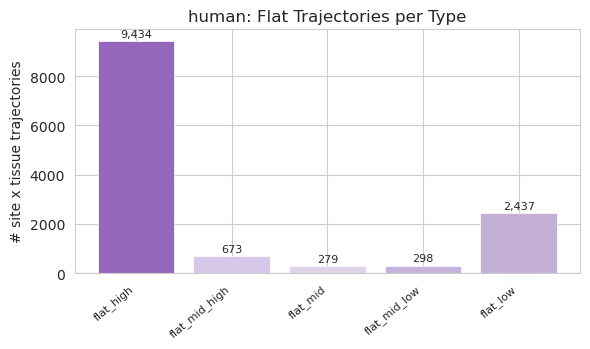

In [8]:
# 1a. Dynamic Trajectory Types
counts_dyn = (
    traj["ClusterShape"]
    .value_counts()
    .reindex(dynamic_shapes)
    .fillna(0)
    .astype(int)
)
plot_counts(
    categories=dynamic_shapes,
    counts=counts_dyn.values,
    colors=[shape_color(s) for s in dynamic_shapes],
    title=f"{SPECIES}: Dynamic Trajectories per Type",
    out_filename="counts_by_trajectory_type_dynamic.png",
    bar_width=0.75,
)

# 1b. Flat Trajectory Types
counts_flat = (
    traj["ClusterShape"].value_counts().reindex(flat_shapes).fillna(0).astype(int)
)
plot_counts(
    categories=flat_shapes,
    counts=counts_flat.values,
    colors=[shape_color(s) for s in flat_shapes],
    title=f"{SPECIES}: Flat Trajectories per Type",
    out_filename="counts_by_trajectory_type_flat.png",
    bar_width=0.85,
)

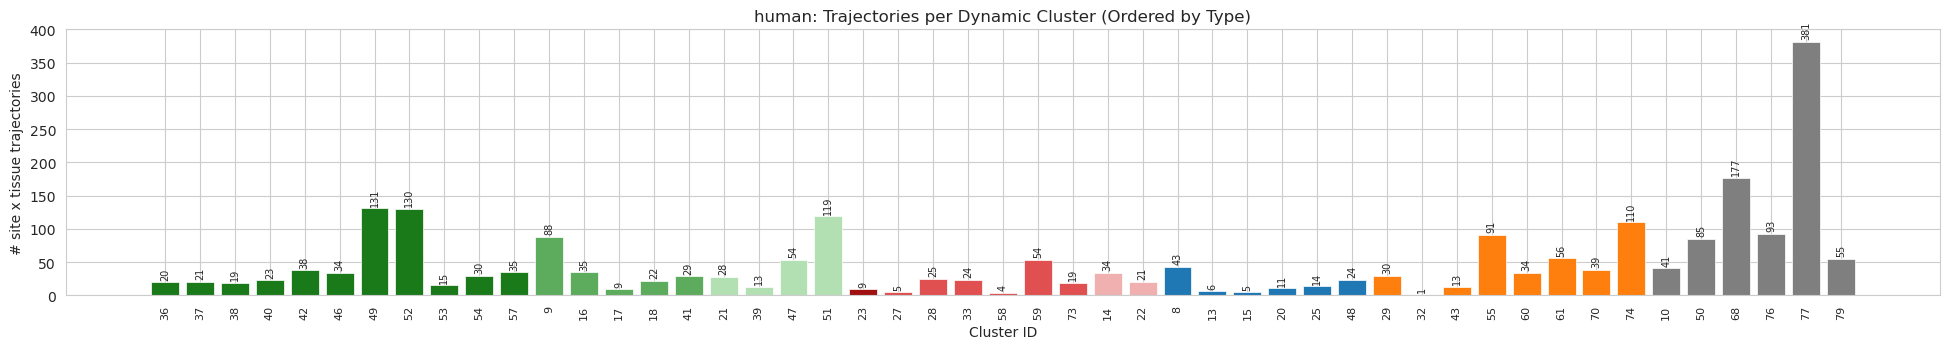

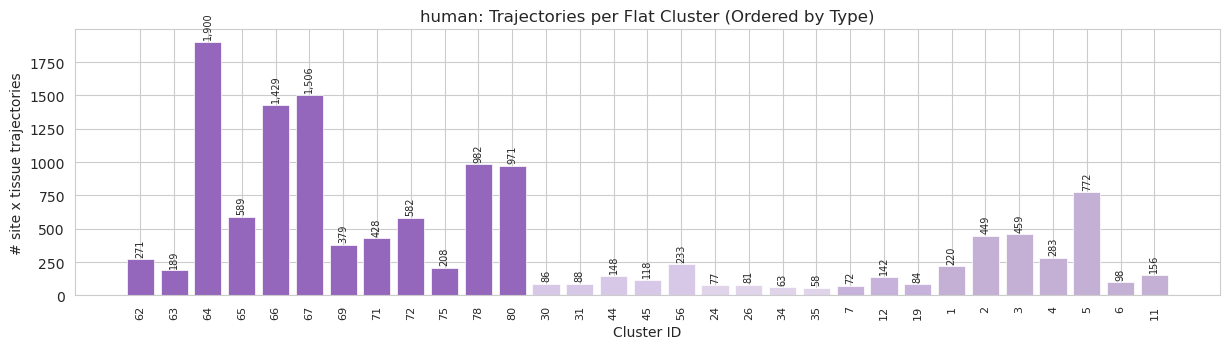

In [9]:
# Map each cluster to its shape
cluster_shapes = traj.groupby("Cluster")["ClusterShape"].first()
all_clusters = traj["Cluster"].unique()

# Sort clusters primarily by SHAPE_ORDER position, secondarily by Cluster ID
sorted_clusters = sorted(
    all_clusters,
    key=lambda c: (
        (
            SHAPE_ORDER.index(cluster_shapes[c])
            if cluster_shapes[c] in SHAPE_ORDER
            else 999
        ),
        c,
    ),
)

# Separate into dynamic vs flat (maintaining SHAPE_ORDER sorting)
dynamic_clusters = [
    c for c in sorted_clusters if not cluster_shapes[c].startswith("flat")
]
flat_clusters = [
    c for c in sorted_clusters if cluster_shapes[c].startswith("flat")
]

# 2a. Dynamic Clusters (Ordered by Trajectory Type)
counts_dyn_clusters = (
    traj["Cluster"].value_counts().reindex(dynamic_clusters).fillna(0).astype(int)
)
plot_counts(
    categories=dynamic_clusters,
    counts=counts_dyn_clusters.values,
    colors=[shape_color(cluster_shapes[c]) for c in dynamic_clusters],
    title=f"{SPECIES}: Trajectories per Dynamic Cluster (Ordered by Type)",
    out_filename="counts_by_cluster_dynamic.png",
    xlabel="Cluster ID",
    bar_width=0.4,
    rotate_labels=len(dynamic_clusters) > 20,
)

# 2b. Flat Clusters (Ordered by Trajectory Type)
counts_flat_clusters = (
    traj["Cluster"].value_counts().reindex(flat_clusters).fillna(0).astype(int)
)
plot_counts(
    categories=flat_clusters,
    counts=counts_flat_clusters.values,
    colors=[shape_color(cluster_shapes[c]) for c in flat_clusters],
    title=f"{SPECIES}: Trajectories per Flat Cluster (Ordered by Type)",
    out_filename="counts_by_cluster_flat.png",
    xlabel="Cluster ID",
    bar_width=0.4,
    rotate_labels=len(flat_clusters) > 20,
)

### 4.2 Prediction accuracy per trajectory type

#### 4.2.1 Correlation

Trajectory metrics (pearson r, cosine, RMSE) within each cluster shape. This shows which
developmental patterns the model captures well and which it struggles with. Only
trajectories with more than a few observed timepoints are informative for Pearson r,
so we require `n_obs_usage > 3`.

In [10]:
from alphagenome_pytorch.plotting.splicing import smooth_all_trajectories

# ── Per-trajectory smoothed true & predicted curves (shared by 4.2 and 4.3) ───
# A trajectory is one site x tissue; averaging collapses any replicate observations.
traj_obs = usage_df.merge(
    traj[join_keys + ["Cluster", "ClusterShape"]].drop_duplicates(join_keys),
    on=join_keys, how="inner",
)

present = [s for s in all_shapes if s in traj_obs["ClusterShape"].values]
traj_obs = traj_obs[traj_obs["ClusterShape"].isin(present)]

TP_GRID = np.array(sorted(traj_obs["timepoint"].unique()), dtype=float)
true_wide = (traj_obs.pivot_table(index=["chr_pos", "tissue"], columns="timepoint",
                                  values="true_usage", aggfunc="mean")
                     .reindex(columns=TP_GRID))
pred_wide = (traj_obs.pivot_table(index=["chr_pos", "tissue"], columns="timepoint",
                                  values="pred_usage", aggfunc="mean")
                     .reindex(columns=TP_GRID))
traj_cluster = (traj_obs.drop_duplicates(["chr_pos", "tissue"])
                        .set_index(["chr_pos", "tissue"])["Cluster"]
                        .reindex(true_wide.index).to_numpy())
traj_n_obs = (traj.drop_duplicates(["chr_pos", "tissue"])
                  .set_index(["chr_pos", "tissue"])["n_obs_usage"]
                  .reindex(true_wide.index).to_numpy())

# GP-smooth each trajectory individually with the same smoother the clustering
# pipeline uses (smooth_all_trajectories -> _smooth_one). It takes read counts to
# decide which timepoints are observed; here a timepoint is observed wherever usage
# is non-NaN. optimize=False fixes the length-scale (fast, ~matches the script's
# roughness); optimize=True fits hyper-parameters per trajectory like the script.
Tv, *_ = smooth_all_trajectories(true_wide, true_wide.notna().astype(int), TP_GRID,
                                 optimize=False, n_jobs=-1)
Pv, *_ = smooth_all_trajectories(pred_wide, pred_wide.notna().astype(int), TP_GRID,
                                 optimize=False, n_jobs=-1)

# Cluster -> shape, and a shape-then-id ordering used for panels/axes
cluster_shape = (traj.dropna(subset=["Cluster"])
                     .drop_duplicates("Cluster")
                     .set_index("Cluster")["ClusterShape"].to_dict())
shape_rank = {s: i for i, s in enumerate(SHAPE_ORDER)}
cluster_order = sorted(
    pd.unique(traj_cluster[~pd.isna(traj_cluster)]),
    key=lambda k: (shape_rank.get(cluster_shape.get(k), len(SHAPE_ORDER)), k),
)
color_by = {k: shape_color(cluster_shape.get(k)) for k in cluster_order}
title_by = {k: cluster_shape.get(k) for k in cluster_order}

print(f"{len(Tv):,} trajectories smoothed  |  {len(cluster_order)} clusters")

15,518 trajectories smoothed  |  80 clusters


/tmp/ipykernel_1873816/3424719256.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="ClusterShape", y=key, order=present,
/tmp/ipykernel_1873816/3424719256.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="ClusterShape", y=key, order=present,
/tmp/ipykernel_1873816/3424719256.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="ClusterShape", y=key, order=present,
/tmp/ipykernel_1873816/3424719256.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e

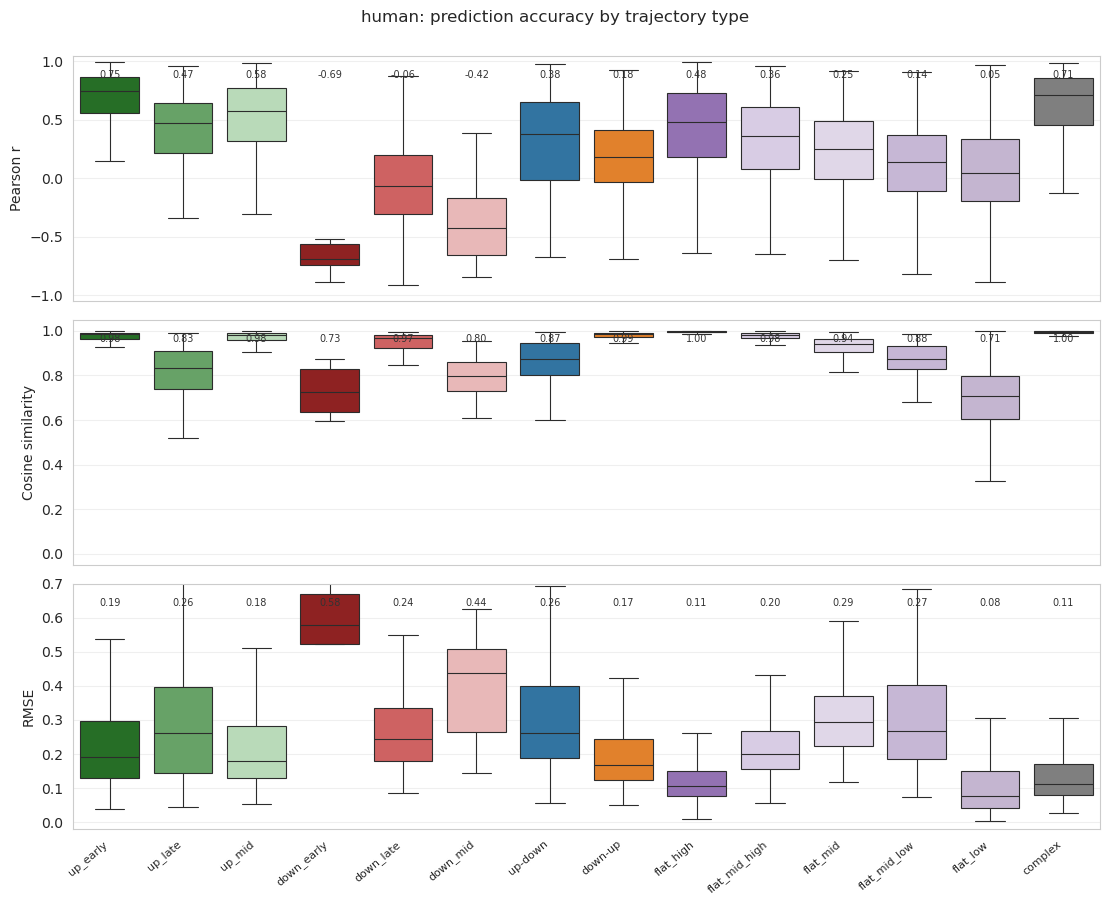

In [11]:
plot_df = traj[traj["n_obs_usage"] > 3].copy()
plot_df["ClusterShape"] = pd.Categorical(plot_df["ClusterShape"], categories=present, ordered=True)

metric_specs = [
    ("pearson_r", "Pearson r", (-1.05, 1.05)),
    ("cosine",    "Cosine similarity", (-0.05, 1.05)),
    ("mae",       "RMSE",       (-0.02, 0.7)),
]
fig, axes = plt.subplots(len(metric_specs), 1,
                         figsize=(max(8, len(present) * 0.8), 3.0 * len(metric_specs)),
                         sharex=True)
pal = {s: shape_color(s) for s in present}
for ax, (key, label, ylim) in zip(axes, metric_specs):
    sns.boxplot(data=plot_df, x="ClusterShape", y=key, order=present,
                palette=pal, showfliers=False, ax=ax, linewidth=0.8)
    med = plot_df.groupby("ClusterShape", observed=True)[key].median().reindex(present)
    for i, m in enumerate(med.values):
        if np.isfinite(m):
            ax.text(i, ylim[1] - 0.06 * (ylim[1] - ylim[0]), f"{m:.2f}",
                    ha="center", va="top", fontsize=7, color="#333")
    ax.set_ylim(*ylim)
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)
axes[-1].set_xticklabels(present, rotation=40, ha="right", fontsize=8)
fig.suptitle(f"{SPECIES}: prediction accuracy by trajectory type", y=1.0)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "metrics_by_trajectory_type.png"), dpi=200, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1873816/3978823638.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[-1].set_xticklabels(


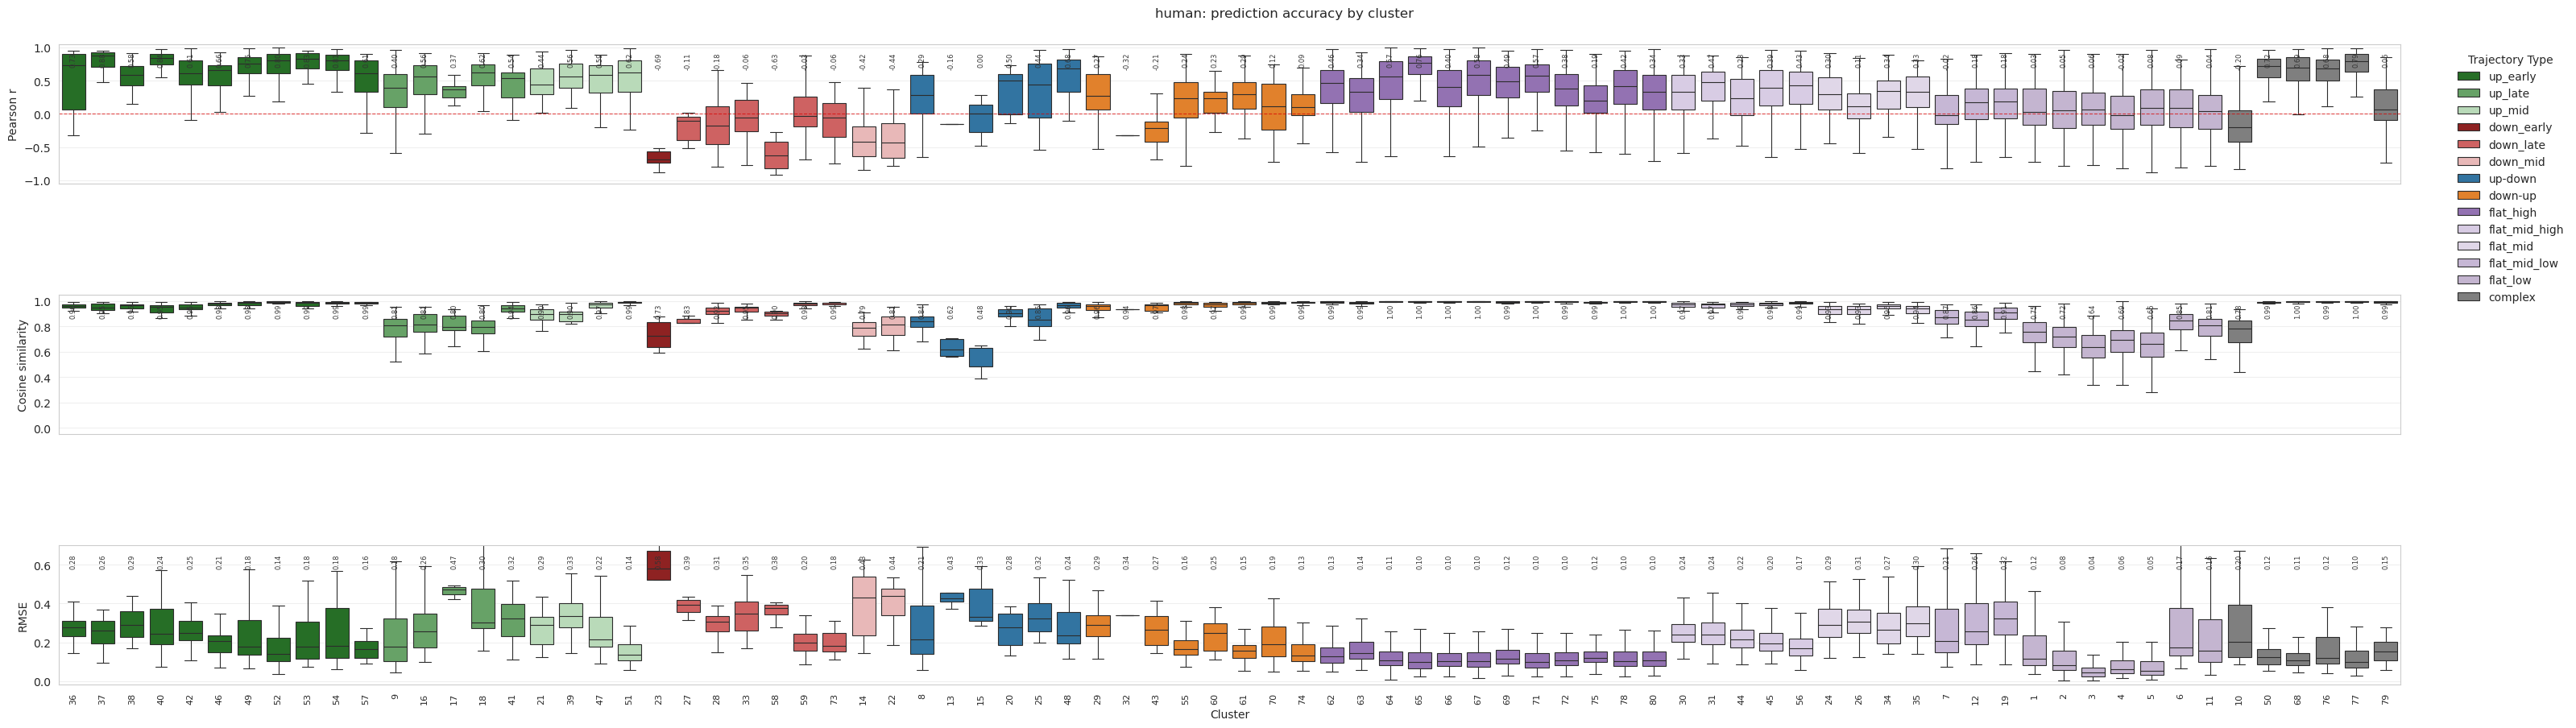

In [12]:
# 1. Ensure Cluster values are integers
plot_df["Cluster"] = plot_df["Cluster"].astype(int)

# 2. Get cluster shapes as a lookup dictionary with integer keys
cluster_shapes = plot_df.groupby("Cluster")["ClusterShape"].first().to_dict()
all_clusters = list(cluster_shapes.keys())

# 3. Sort cluster IDs by SHAPE_ORDER, then Cluster ID
present_clusters = sorted(
    all_clusters,
    key=lambda c: (
        (
            SHAPE_ORDER.index(cluster_shapes[c])
            if cluster_shapes[c] in SHAPE_ORDER
            else 999
        ),
        c,
    ),
)

# 4. Set categorical ordering for Cluster column
plot_df["Cluster"] = pd.Categorical(
    plot_df["Cluster"], categories=present_clusters, ordered=True
)

# 5. Palette mapped to ClusterShape (types) instead of individual clusters
pal = {s: shape_color(s) for s in present}

# 6. Plot layout
fig, axes = plt.subplots(
    len(metric_specs),
    1,
    figsize=(
        max(8, len(present_clusters) * 0.4),
        3.0 * len(metric_specs),
    ),
    sharex=True,
)

for i_ax, (ax, (key, label, ylim)) in enumerate(zip(axes, metric_specs)):
    # Use hue="ClusterShape" with dodge=False so boxes color by shape type
    sns.boxplot(
        data=plot_df,
        x="Cluster",
        y=key,
        order=present_clusters,
        hue="ClusterShape",
        palette=pal,
        dodge=False,
        showfliers=False,
        ax=ax,
        linewidth=0.8,
    )

    # Show legend only on the first subplot to save space
    if i_ax == 0:
        sns.move_legend(
            ax,
            "upper left",
            bbox_to_anchor=(1.02, 1),
            title="Trajectory Type",
            frameon=False,
        )
    else:
        ax.get_legend().remove()

    # Show line at y=0 for the first plot (Pearson r) to indicate no correlation
    if i_ax == 0:
        ax.axhline(0, color="#DA0000", lw=0.8, ls="--", alpha=0.7)

    # Median annotations per cluster
    med = (
        plot_df.groupby("Cluster", observed=True)[key]
        .median()
        .reindex(present_clusters)
    )
    for i, m in enumerate(med.values):
        if np.isfinite(m):
            rot = 90 if len(present_clusters) > 25 else 0
            ax.text(
                i,
                ylim[1] - 0.06 * (ylim[1] - ylim[0]),
                f"{m:.2f}",
                ha="center",
                va="top",
                fontsize=6,
                color="#333",
                rotation=rot,
            )

    ax.set_ylim(*ylim)
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.3)

rot_ticks = 90 if len(present_clusters) > 20 else 40
ha_ticks = "center" if len(present_clusters) > 20 else "right"
axes[-1].set_xticklabels(
    present_clusters, rotation=rot_ticks, ha=ha_ticks, fontsize=8
)
axes[-1].set_xlabel("Cluster")

fig.suptitle(f"{SPECIES}: prediction accuracy by cluster", y=1.0)
plt.tight_layout()
fig.savefig(
    os.path.join(OUT_DIR, "metrics_by_cluster.png"),
    dpi=200,
    bbox_inches="tight",
)
plt.show()

#### 4.2.2. Classification accuracy

Beyond *how close* the predicted curve is, we can ask whether it has the **right shape**:
run each predicted trajectory through the very same `classify_cluster_shape` used to label
the clusters, and check whether it lands on the trajectory's true label
(true = `up_early` → predicted = `up_early`).

Two reference points are reported, because the true label is a **cluster-level** annotation
(derived from the cluster *mean*), while classification here is **per trajectory**:

- **Model accuracy** — predicted curve's shape vs the trajectory's cluster label.
- **Self-consistency ceiling** — the *true* curve's own shape vs its cluster label. Individual
  true trajectories are noisier than their cluster mean, so this is well below 100% and is the
  realistic ceiling for the model number. Accuracy alone is easy to misread without it.

Evaluated 15,001 trajectories (n_obs_usage > 3)
  Correctly classified (predicted shape == cluster label): 1,847 / 15,001  = 12.3%
  Self-consistency ceiling (true curve  == cluster label): 43.2%
  -> model reaches 28% of the achievable ceiling


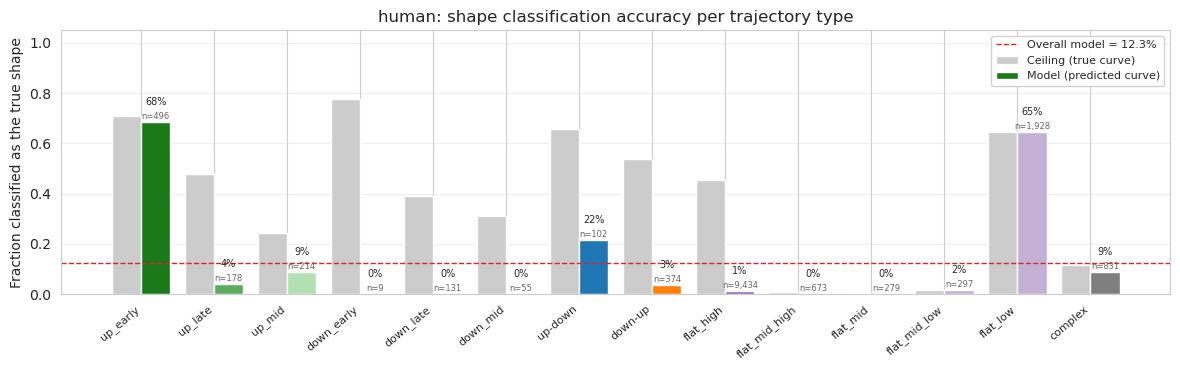

,n,model_acc,ceiling_acc
shape,,,
up_early,496,0.683,0.710
up_late,178,0.039,0.478
up_mid,214,0.089,0.243
down_early,9,0.000,0.778
down_late,131,0.000,0.389
down_mid,55,0.000,0.309
up-down,102,0.216,0.657
down-up,374,0.035,0.537
flat_high,9434,0.013,0.456


In [13]:
from alphagenome_pytorch.plotting.splicing import classify_cluster_shape

# Classify each trajectory's own curve with the classifier used to label clusters.
# Restrict to well-observed trajectories with a valid smoothed curve (same
# n_obs_usage > 3 filter as the metric boxplots above).
keep = (np.isfinite(Tv).all(axis=1) & np.isfinite(Pv).all(axis=1)
        & ~pd.isna(traj_cluster) & (np.nan_to_num(traj_n_obs, nan=0) > 3))
idx = np.where(keep)[0]

true_label  = np.array([cluster_shape.get(c) for c in traj_cluster], dtype=object)
pred_shape  = np.full(len(Tv), None, dtype=object)   # shape of the PREDICTED curve
self_shape  = np.full(len(Tv), None, dtype=object)   # shape of the TRUE curve itself
for i in idx:
    pred_shape[i] = classify_cluster_shape(Pv[i])
    self_shape[i] = classify_cluster_shape(Tv[i])

acc_model   = float((pred_shape[idx] == true_label[idx]).mean())
acc_ceiling = float((self_shape[idx] == true_label[idx]).mean())
n_correct   = int((pred_shape[idx] == true_label[idx]).sum())

print(f"Evaluated {len(idx):,} trajectories (n_obs_usage > 3)")
print(f"  Correctly classified (predicted shape == cluster label): "
      f"{n_correct:,} / {len(idx):,}  = {acc_model:.1%}")
print(f"  Self-consistency ceiling (true curve  == cluster label): {acc_ceiling:.1%}")
if acc_ceiling > 0:
    print(f"  -> model reaches {acc_model / acc_ceiling:.0%} of the achievable ceiling")

# ── Per-shape accuracy (recall) ───────────────────────────────────────────────
rows = []
for s in present:
    m = idx[true_label[idx] == s]
    if len(m) == 0:
        continue
    rows.append(dict(shape=s, n=len(m),
                     model_acc=float((pred_shape[m] == s).mean()),
                     ceiling_acc=float((self_shape[m] == s).mean())))
shape_acc = pd.DataFrame(rows).set_index("shape")

fig, ax = plt.subplots(figsize=(max(7, len(shape_acc) * 0.85), 3.8))
x = np.arange(len(shape_acc))
ax.bar(x - 0.2, shape_acc["ceiling_acc"], width=0.4, color="#cccccc",
       edgecolor="white", label="Ceiling (true curve)")
ax.bar(x + 0.2, shape_acc["model_acc"], width=0.4,
       color=[shape_color(s) for s in shape_acc.index],
       edgecolor="white", label="Model (predicted curve)")
for xi, (mv, n) in enumerate(zip(shape_acc["model_acc"], shape_acc["n"])):
    ax.text(xi + 0.2, mv + 0.06, f"{mv:.0%}", ha="center", va="bottom", fontsize=7)
    ax.text(xi + 0.2, mv + 0.04, f"n={n:,}", ha="center", va="top", fontsize=6, color="#666")
ax.axhline(acc_model, color="#d62728", ls="--", lw=1,
           label=f"Overall model = {acc_model:.1%}")
ax.set_xticks(x); ax.set_xticklabels(shape_acc.index, rotation=40, ha="right", fontsize=8)
ax.set_ylim(0, 1.05); ax.set_ylabel("Fraction classified as the true shape")
ax.set_title(f"{SPECIES}: shape classification accuracy per trajectory type")
ax.legend(fontsize=8, framealpha=0.9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "shape_classification_accuracy.png"),
            dpi=200, bbox_inches="tight")
plt.show()

display(shape_acc.round(3))

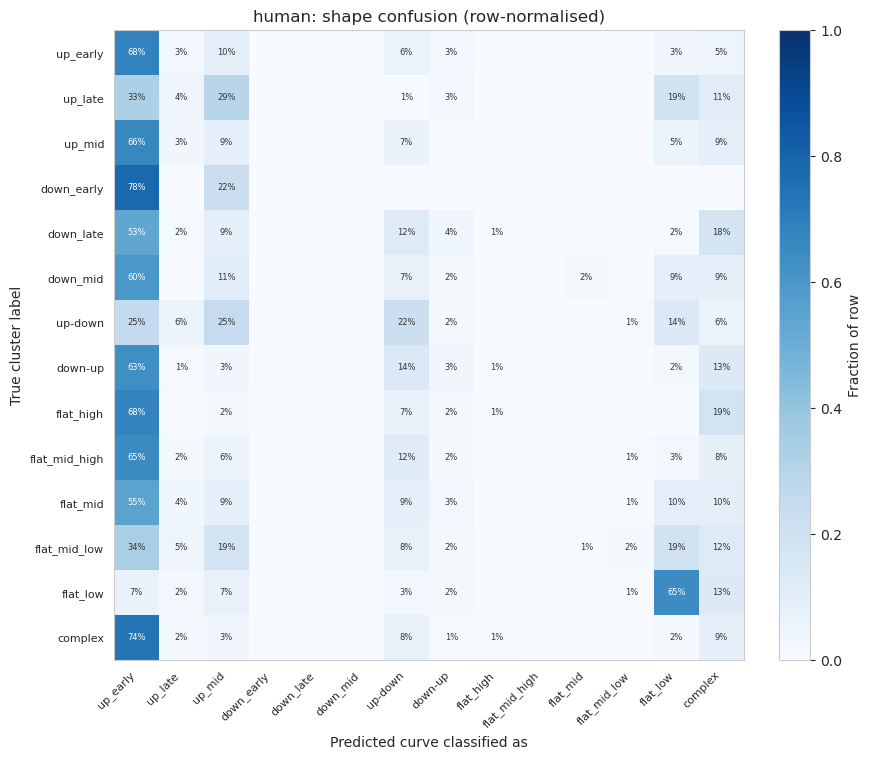

Most common misclassifications (fraction of the true row):
      down_early -> up_early       77.8%
         complex -> up_early       73.8%
       flat_high -> up_early       67.9%
          up_mid -> up_early       66.4%
   flat_mid_high -> up_early       65.1%
         down-up -> up_early       63.4%
        down_mid -> up_early       60.0%
        flat_mid -> up_early       54.8%


In [14]:
# ── Confusion matrix: true cluster label vs shape of the predicted curve ──────
labels = [s for s in SHAPE_ORDER
          if s in set(true_label[idx]) or s in set(pred_shape[idx])]
cm = (pd.crosstab(pd.Series(true_label[idx], name="True (cluster label)"),
                  pd.Series(pred_shape[idx], name="Predicted (classified curve)"))
        .reindex(index=labels, columns=labels, fill_value=0))
cm_norm = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.62),
                                max(5, len(labels) * 0.55)))
im = ax.imshow(cm_norm.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
for r in range(len(labels)):
    for c in range(len(labels)):
        v = cm_norm.values[r, c]
        if np.isfinite(v) and v > 0.005:
            ax.text(c, r, f"{v:.0%}", ha="center", va="center", fontsize=6,
                    color="white" if v > 0.5 else "#333")
ax.set_xlabel("Predicted curve classified as"); ax.set_ylabel("True cluster label")
ax.set_title(f"{SPECIES}: shape confusion (row-normalised)")
ax.grid(False); ax.set_facecolor("#f7f7f7")
fig.colorbar(im, ax=ax, fraction=0.046, label="Fraction of row")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "shape_confusion_matrix.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# Most common confusions (off-diagonal)
off = (cm_norm.where(~np.eye(len(labels), dtype=bool))
              .stack().sort_values(ascending=False).head(8))
print("Most common misclassifications (fraction of the true row):")
for (t, pshape), v in off.items():
    if v > 0:
        print(f"  {t:>14s} -> {pshape:<14s} {v:.1%}")

The shape-level view pools clusters that share a label, which hides the fact that a single
label (e.g. `up_early`) can absorb predictions from many different clusters. Here the same
evaluation is broken down **per cluster**, ordered by shape then cluster id (as in 4.3):

- **accuracy per cluster** — model vs the self-consistency ceiling, so a cluster the model
  genuinely fails on is distinguishable from one whose trajectories are just noisy;
- **what each cluster's predictions actually get called** — the full predicted-shape
  composition per cluster, which shows directly whether predictions collapse onto one
  dominant shape rather than being spread over plausible neighbours.

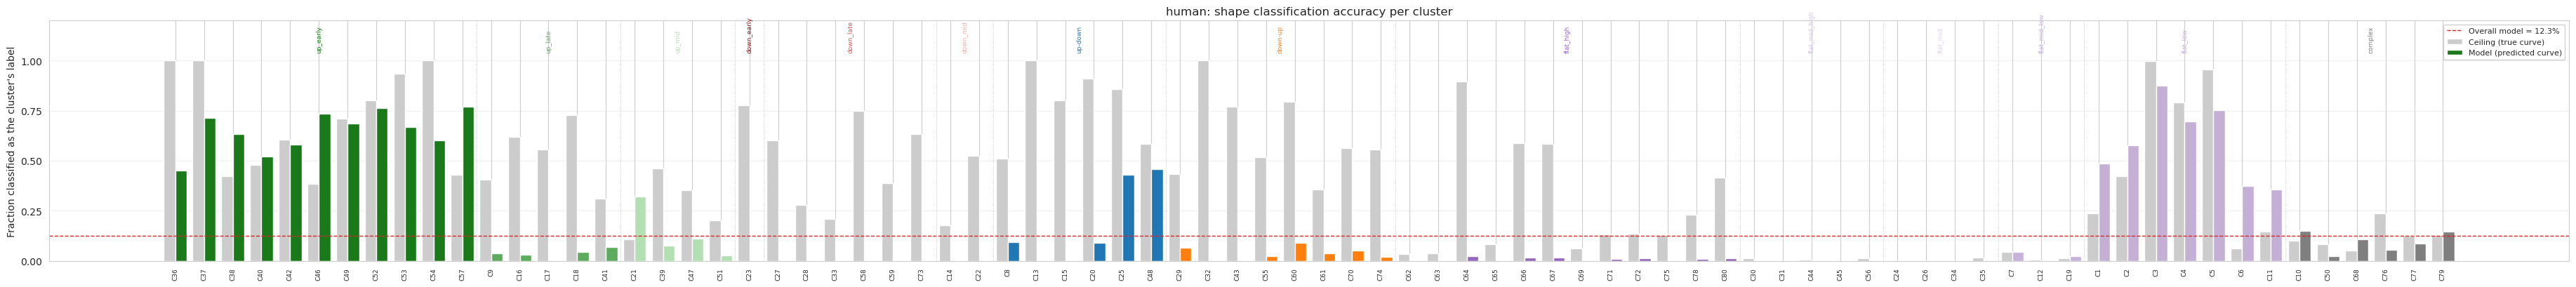

,ClusterShape,n,model_acc,ceiling_acc,top_pred,top_pred_frac
Cluster,,,,,,
36,up_early,20,0.450,1.000,up_early,0.450
37,up_early,21,0.714,1.000,up_early,0.714
38,up_early,19,0.632,0.421,up_early,0.632
40,up_early,23,0.522,0.478,up_early,0.522
42,up_early,38,0.579,0.605,up_early,0.579
...,...,...,...,...,...,...
50,complex,85,0.024,0.082,up_early,0.812
68,complex,177,0.107,0.051,up_early,0.763
76,complex,93,0.054,0.237,up_early,0.731


In [15]:
# ── Per-cluster accuracy (model vs ceiling) ───────────────────────────────────
rows = []
for k in cluster_order:
    m = idx[traj_cluster[idx] == k]
    if len(m) == 0:
        continue
    lab = cluster_shape.get(k)
    vc  = pd.Series(list(pred_shape[m])).value_counts(normalize=True)
    rows.append(dict(
        Cluster=int(k), ClusterShape=lab, n=len(m),
        model_acc=float((pred_shape[m] == lab).mean()),
        ceiling_acc=float((self_shape[m] == lab).mean()),
        top_pred=vc.index[0], top_pred_frac=float(vc.iloc[0]),
    ))
cluster_acc = pd.DataFrame(rows).set_index("Cluster")

fig, ax = plt.subplots(figsize=(max(9, len(cluster_acc) * 0.46), 4.2))
x = np.arange(len(cluster_acc))
ax.bar(x - 0.2, cluster_acc["ceiling_acc"], width=0.4, color="#cccccc",
       edgecolor="white", label="Ceiling (true curve)")
ax.bar(x + 0.2, cluster_acc["model_acc"], width=0.4,
       color=[shape_color(s) for s in cluster_acc["ClusterShape"]],
       edgecolor="white", label="Model (predicted curve)")
ax.axhline(acc_model, color="#d62728", ls="--", lw=1,
           label=f"Overall model = {acc_model:.1%}")

# separators + shape name between groups of clusters sharing a label
shapes_seq = list(cluster_acc["ClusterShape"])
start = 0
for i in range(1, len(shapes_seq) + 1):
    if i == len(shapes_seq) or shapes_seq[i] != shapes_seq[start]:
        if i < len(shapes_seq):
            ax.axvline(i - 0.5, color="#bbbbbb", lw=0.6, ls=":")
        ax.text((start + i - 1) / 2, 1.04, shapes_seq[start], ha="center", va="bottom",
                fontsize=6.5, rotation=90, color=shape_color(shapes_seq[start]))
        start = i

ax.set_xticks(x)
ax.set_xticklabels([f"C{c}" for c in cluster_acc.index], rotation=90, fontsize=6.5)
ax.set_ylim(0, 1.2)
ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.set_ylabel("Fraction classified as the cluster's label")
ax.set_title(f"{SPECIES}: shape classification accuracy per cluster")
ax.legend(fontsize=8, loc="upper right", framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "shape_classification_accuracy_by_cluster.png"),
            dpi=200, bbox_inches="tight")
plt.show()

display(cluster_acc.round(3))

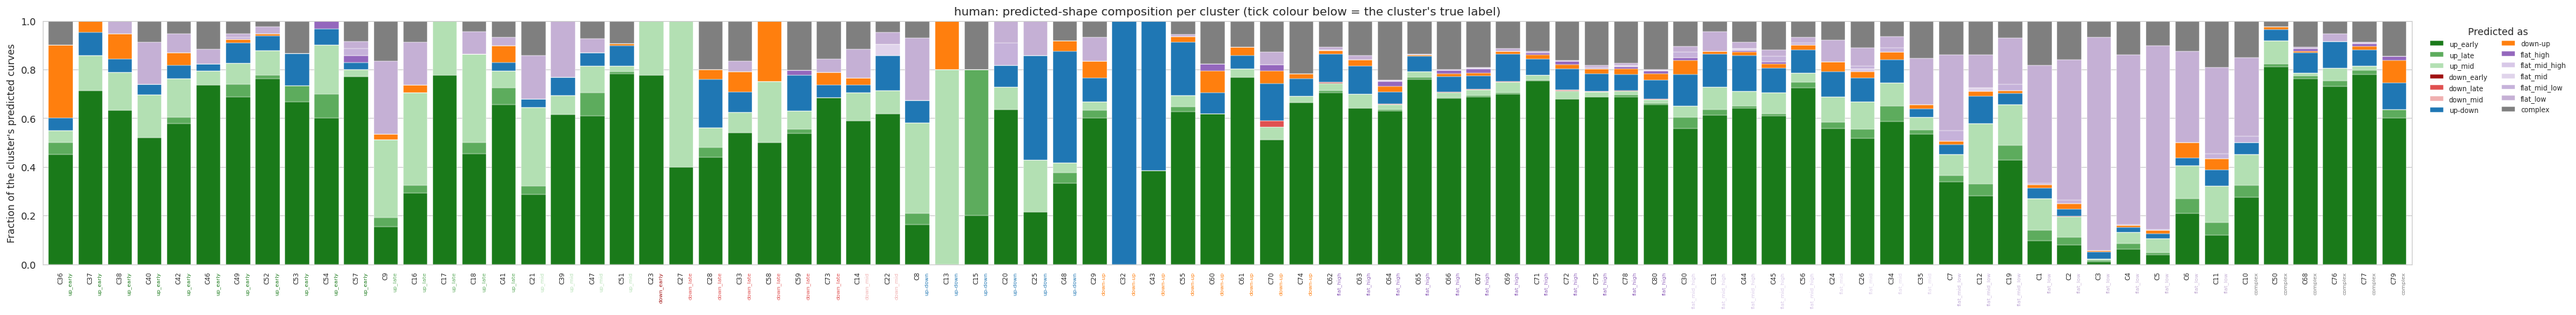

Shape distribution over all evaluated trajectories (predicted_curve vs the true labels):


,true_label,predicted_curve,true_curve,pred_minus_true
up_early,0.033,0.583,0.126,0.550
complex,0.055,0.157,0.163,0.102
up-down,0.007,0.068,0.171,0.061
up_mid,0.014,0.045,0.029,0.031
up_late,0.012,0.013,0.026,0.001
down_early,0.001,0.001,0.005,0.000
down_mid,0.004,0.000,0.004,-0.003
down-up,0.025,0.019,0.090,-0.006
down_late,0.009,0.001,0.013,-0.008
flat_mid_low,0.020,0.003,0.000,-0.017


Most over-predicted shape: up_early  (58.3% of predictions vs 3.3% of true labels)
Clusters where >50% of predictions collapse onto one shape: 63 / 80


In [16]:
# ── What do each cluster's predictions actually get classified as? ────────────
pred_labels = [s for s in SHAPE_ORDER
               if s in set(pred_shape[idx]) or s in set(true_label[idx])]
comp = pd.DataFrame(0.0, index=[int(k) for k in cluster_order], columns=pred_labels)
for k in cluster_order:
    m = idx[traj_cluster[idx] == k]
    if len(m) == 0:
        continue
    vc = pd.Series(list(pred_shape[m])).value_counts(normalize=True)
    comp.loc[int(k), vc.index] = vc.values

fig, ax = plt.subplots(figsize=(max(9, len(comp) * 0.46), 4.6))
bottom = np.zeros(len(comp))
for s in pred_labels:
    ax.bar(np.arange(len(comp)), comp[s].values, bottom=bottom, width=0.82,
           color=shape_color(s), edgecolor="white", linewidth=0.3, label=s)
    bottom += comp[s].values

# mark each cluster's TRUE label underneath
for xi, k in enumerate(comp.index):
    ax.text(xi + 0.4, -0.03, cluster_shape.get(float(k), cluster_shape.get(k, "")),
            ha="right", va="top", fontsize=5.5, rotation=90,
            color=shape_color(cluster_shape.get(float(k), cluster_shape.get(k))))

ax.set_xticks(np.arange(len(comp)))
ax.set_xticklabels([f"C{c}" for c in comp.index], rotation=90, fontsize=6.5)
ax.set_ylim(0, 1); ax.set_xlim(-0.6, len(comp) - 0.4)
ax.set_ylabel("Fraction of the cluster's predicted curves")
ax.set_title(f"{SPECIES}: predicted-shape composition per cluster "
             f"(tick colour below = the cluster's true label)")
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.005, 1), loc="upper left",
          frameon=False, title="Predicted as")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "predicted_shape_composition_by_cluster.png"),
            dpi=200, bbox_inches="tight")
plt.show()

# ── Is there a global bias toward one shape? ──────────────────────────────────
dist = pd.DataFrame({
    "true_label":     pd.Series(list(true_label[idx])).value_counts(normalize=True),
    "predicted_curve": pd.Series(list(pred_shape[idx])).value_counts(normalize=True),
    "true_curve":     pd.Series(list(self_shape[idx])).value_counts(normalize=True),
}).reindex(pred_labels).fillna(0.0)
dist["pred_minus_true"] = dist["predicted_curve"] - dist["true_label"]
print("Shape distribution over all evaluated trajectories "
      "(predicted_curve vs the true labels):")
display(dist.sort_values("pred_minus_true", ascending=False).round(3))
over = dist["pred_minus_true"].idxmax()
print(f"Most over-predicted shape: {over}  "
      f"({dist.loc[over, 'predicted_curve']:.1%} of predictions vs "
      f"{dist.loc[over, 'true_label']:.1%} of true labels)")
print(f"Clusters where >50% of predictions collapse onto one shape: "
      f"{int((comp.max(axis=1) > 0.5).sum())} / {len(comp)}")

### 4.3 True vs predicted profile per cluster

Rendered with the shared `plot_cluster_trajectory_profiles` helper — the same style as
the cluster profiles saved by [scripts/cluster_trajectories.py](../../scripts/cluster_trajectories.py)
and [splice_trajectory_clustering.ipynb](splice_trajectory_clustering.ipynb): thin
individual trajectories + a mean ± SD band + a bold **plain-mean** line, one panel per
cluster, coloured by shape. **True** is solid, **predicted** dashed.

To match the clustering plots, each trajectory is GP-smoothed **individually first** using
the very same `smooth_all_trajectories` / `_smooth_one` as the clustering pipeline, and the
bold line is the plain average of those smooth curves. Smoothing the *average* instead
over-smooths, and a plain average of the *raw* trajectories is far too rough — the
smoothing has to be per-trajectory.

`optimize=False` holds the length-scale fixed (fast, and closely matches the script's
roughness); pass `optimize=True` to fit hyper-parameters per trajectory exactly like the
script, at a large speed cost.

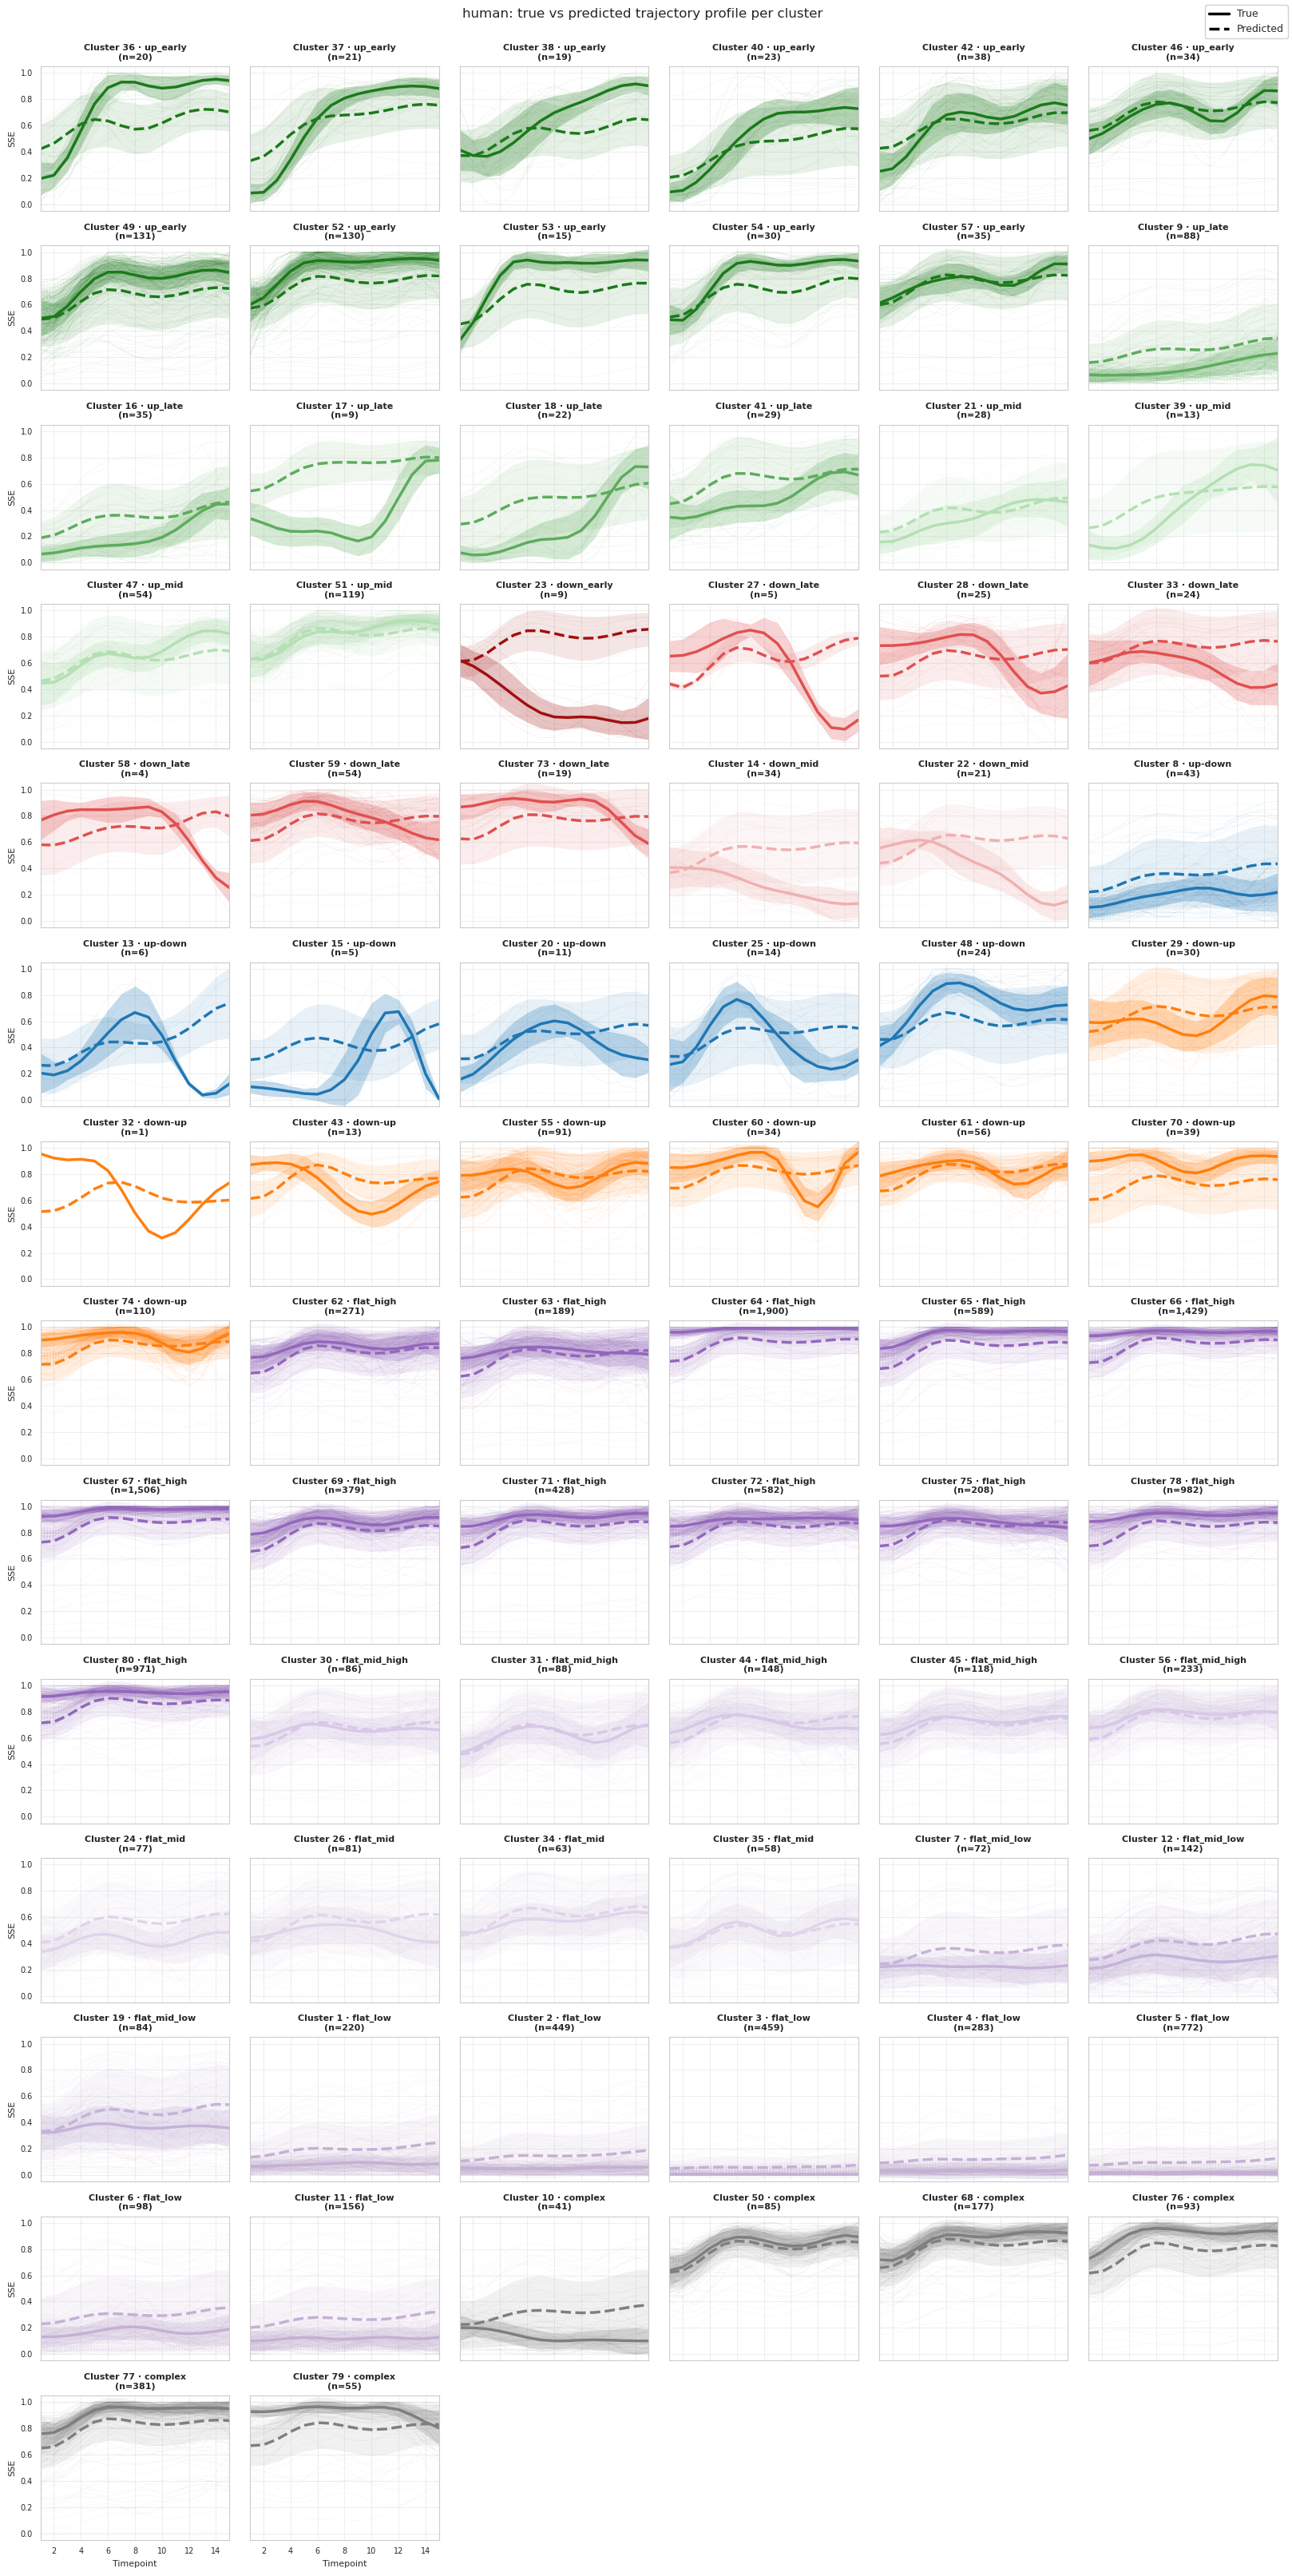

In [17]:
from alphagenome_pytorch.plotting.splicing import plot_cluster_trajectory_profiles

# Tv / Pv / traj_cluster / cluster_order / colours come from the shared prep in 4.2
fig = plot_cluster_trajectory_profiles(
    grid=TP_GRID, features=Tv, labels=traj_cluster,
    features2=Pv, series_labels=("True", "Predicted"),
    cluster_order=cluster_order, color_by=color_by, title_by=title_by,
    n_cols=6, n_draw=120,
    ylabel="SSE", xlabel="Timepoint",
    suptitle=f"{SPECIES}: true vs predicted trajectory profile per cluster",
)
fig.savefig(os.path.join(OUT_DIR, "true_vs_pred_profile_by_cluster.png"),
            dpi=200, bbox_inches="tight")
plt.show()

### 4.4 Example sites per trajectory type

Individual trajectories give a feel for the spread behind the averages. For a chosen
cluster shape we plot the true (solid) and predicted (dashed) SSE of a few example sites,
picking the best-correlated ones so the intended pattern is clearly visible.

In [18]:
def plot_examples(shape, n=6, rank_by="pearson_r", ascending=False,
                  min_obs=6, random=False, seed=0, tissue=None):
    """Plot true (solid) vs predicted (dashed) trajectories for example sites of a shape."""
    cand = traj[(traj["ClusterShape"] == shape) & (traj["n_obs_usage"] >= min_obs)].copy()
    if cand.empty:
        print(f"No sites with n_obs_usage >= {min_obs} for shape '{shape}'")
        return
    if tissue is not None:
        cand = cand[cand["tissue"] == tissue]
    if random:
        cand = cand.sample(min(n, len(cand)), random_state=seed)
    else:
        cand = cand.sort_values(rank_by, ascending=ascending).head(n)

    color  = shape_color(shape)
    n_cols = min(3, len(cand))
    n_rows = (len(cand) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.6, n_rows * 2.8),
                             squeeze=False, sharey=True)
    for ax_i, (_, row) in enumerate(cand.iterrows()):
        ax  = axes[ax_i // n_cols, ax_i % n_cols]
        sub = usage_df[(usage_df["chr_pos"] == row["chr_pos"]) &
                       (usage_df["tissue"] == row["tissue"])].sort_values("timepoint")
        ax.plot(sub["timepoint"], sub["true_usage"], "-o", color=color, ms=4, lw=1.6, label="True")
        ax.plot(sub["timepoint"], sub["pred_usage"], "--x", color=color, ms=5, lw=1.6, label="Predicted")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{row['tissue']} {row['chr_pos']}\n"
                     f"r={row['pearson_r']:.2f}  RMSE={row['mae']:.2f}", fontsize=8)
        ax.grid(alpha=0.3)
        if ax_i % n_cols == 0:
            ax.set_ylabel("SSE")
        if ax_i // n_cols == n_rows - 1:
            ax.set_xlabel("Timepoint")
    for j in range(len(cand), n_rows * n_cols):
        axes[j // n_cols, j % n_cols].set_visible(False)
    fig.suptitle(f"{SPECIES} — '{shape}' examples", y=1.0, fontsize=11, fontweight="bold")
    plt.tight_layout()
    return fig

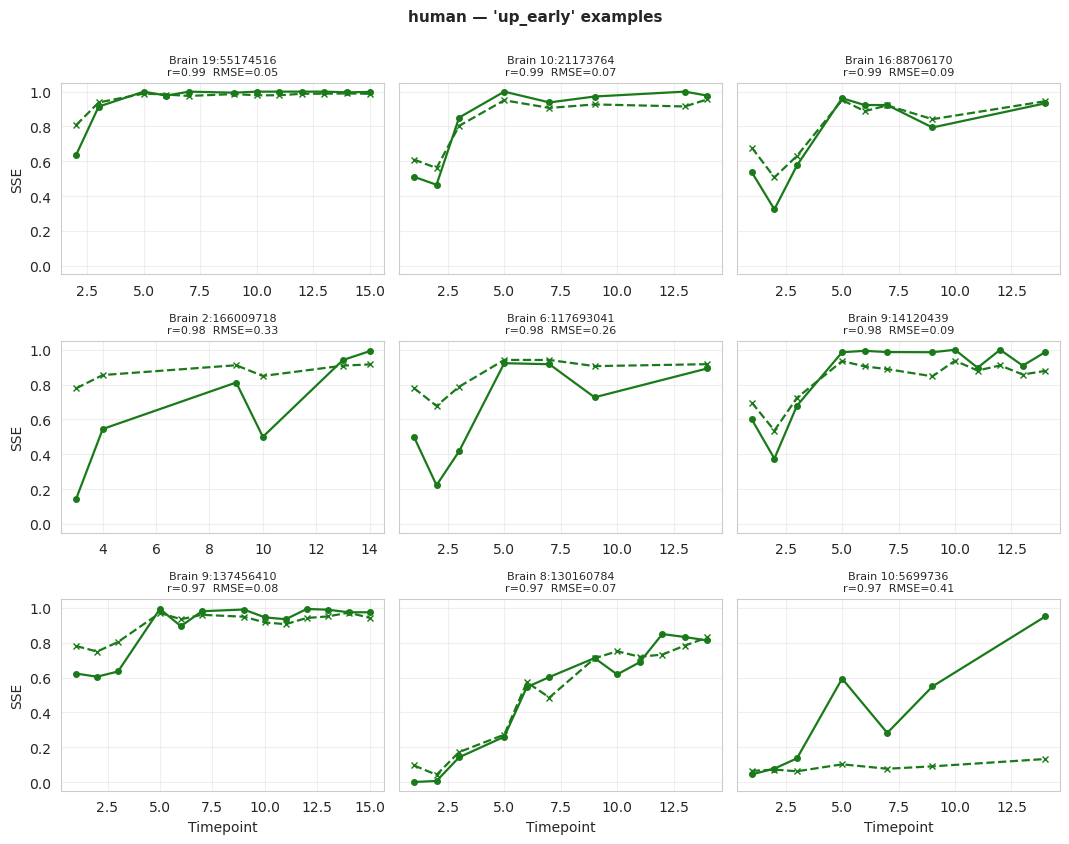

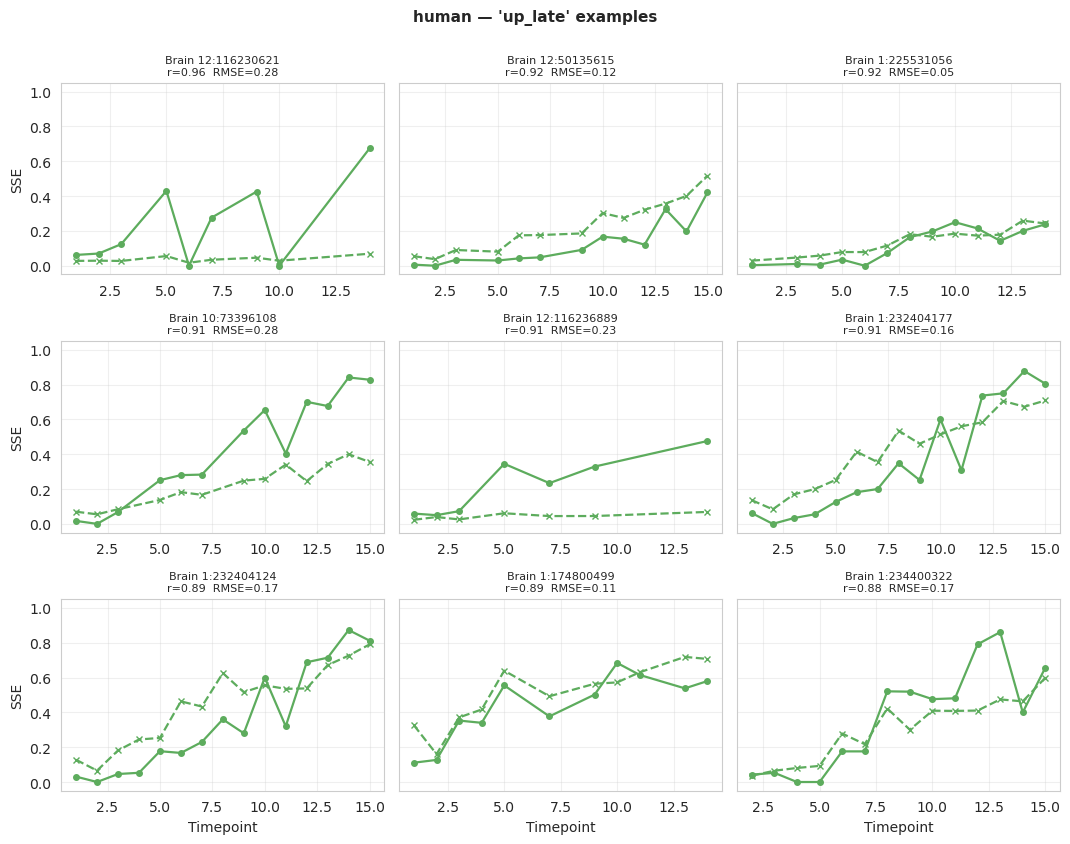

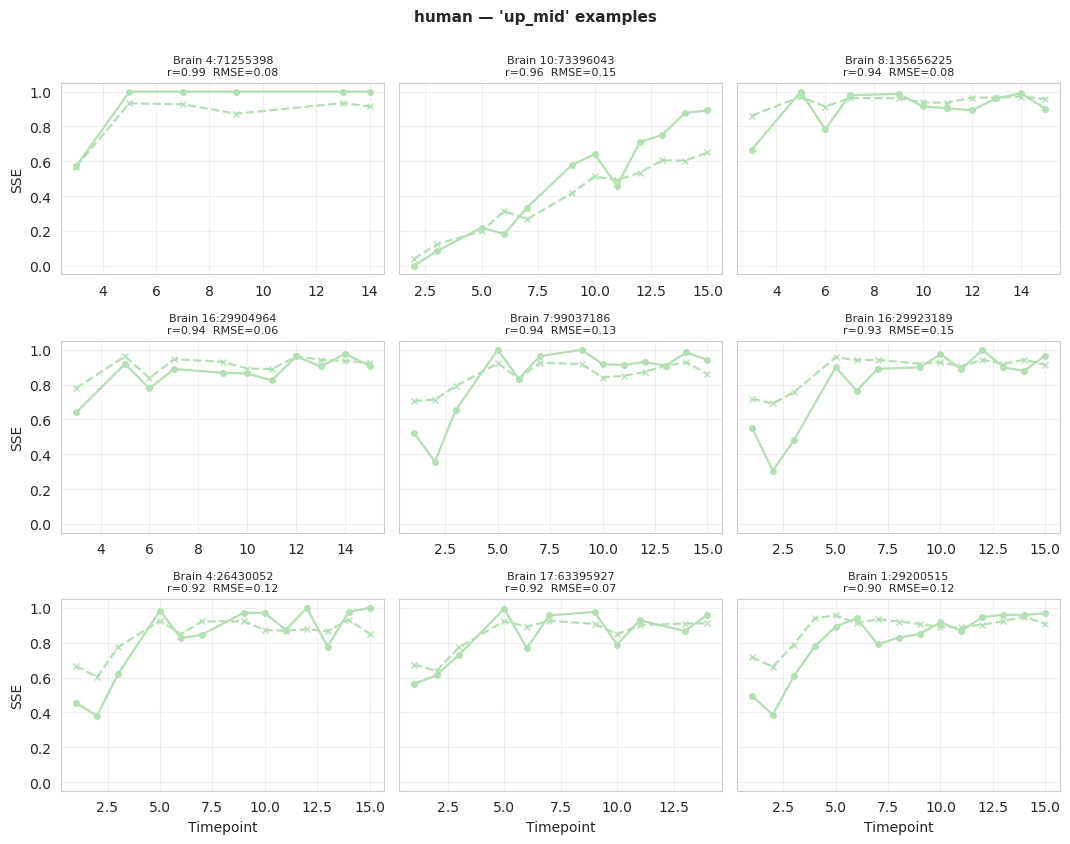

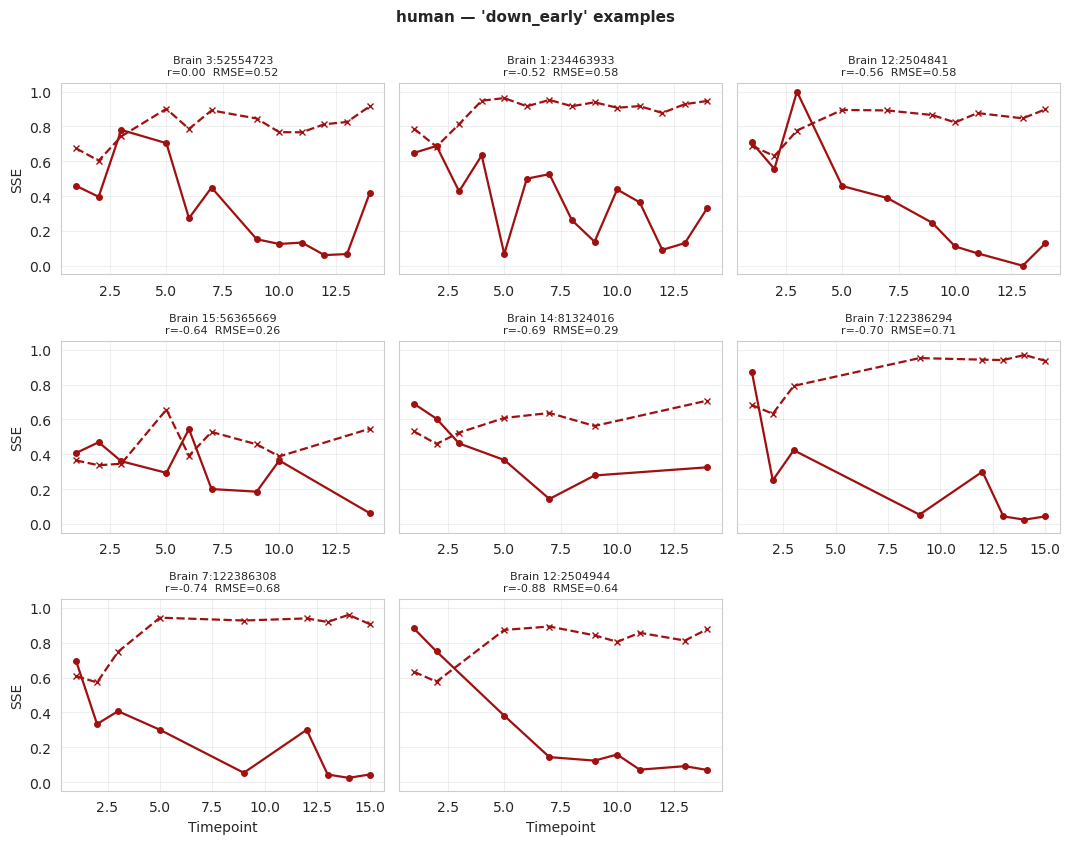

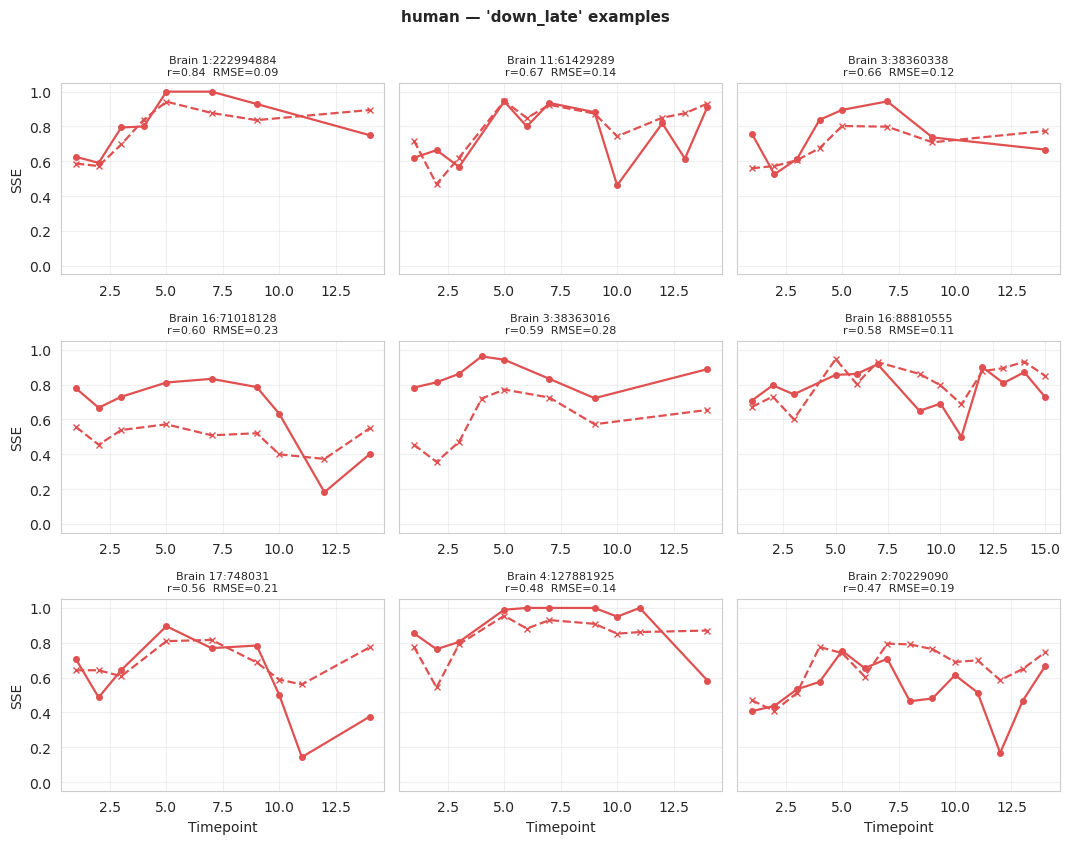

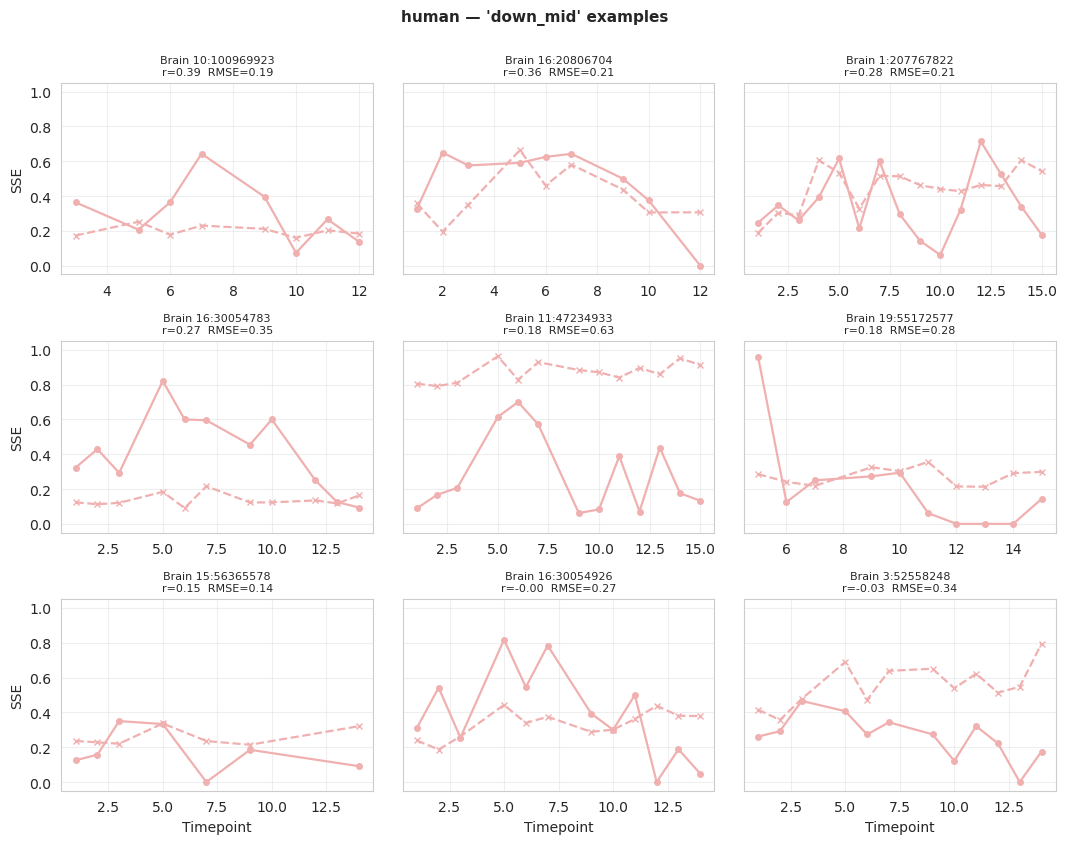

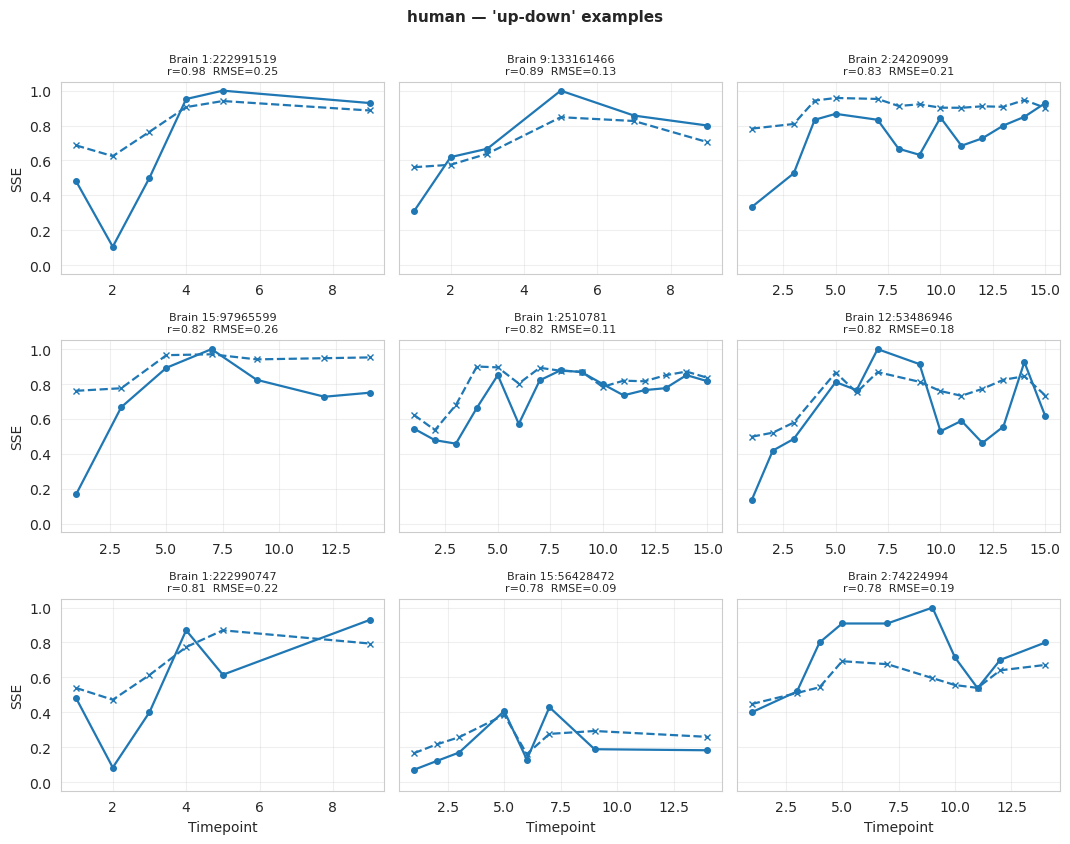

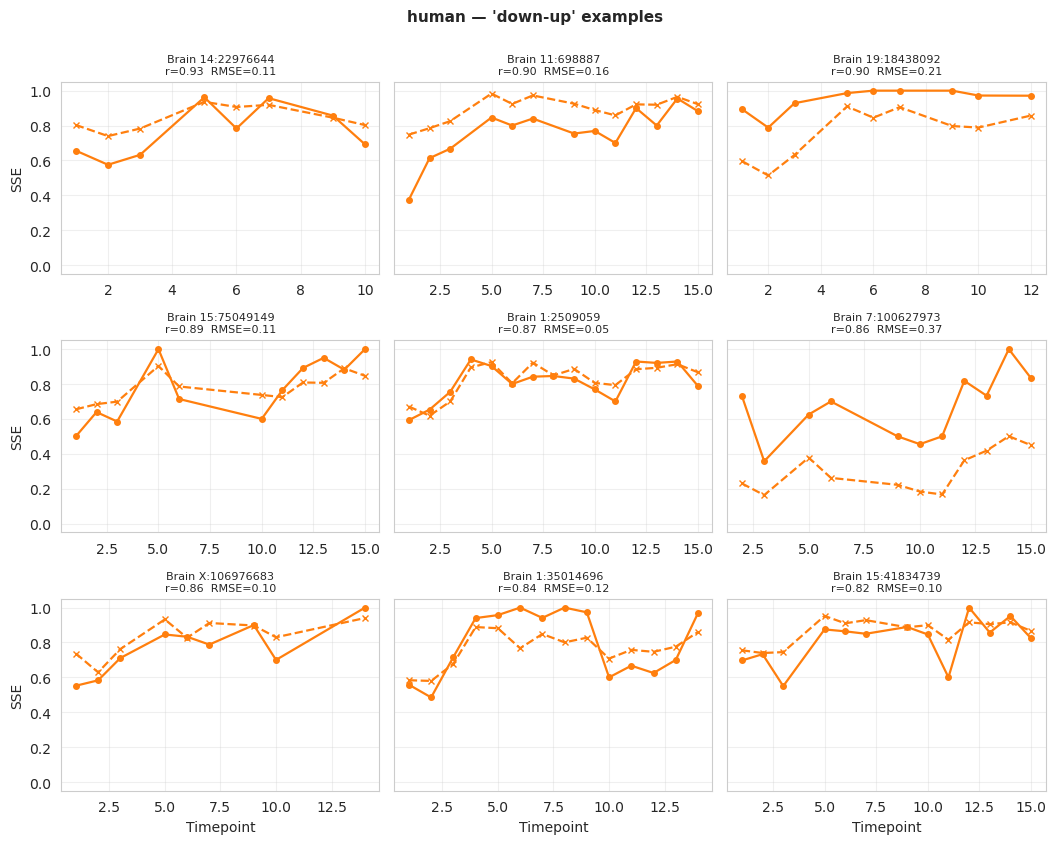

In [20]:
# Example: the best correlated sites of a given trajectory shape (except flat/complex)
plot_shapes = [s for s in SHAPE_ORDER if s not in ("flat_high", "flat_mid_high", "flat_mid", "flat_mid_low", "flat_low", "complex")]
for shape in plot_shapes:
    plot_examples(shape, tissue='Brain', n=9)

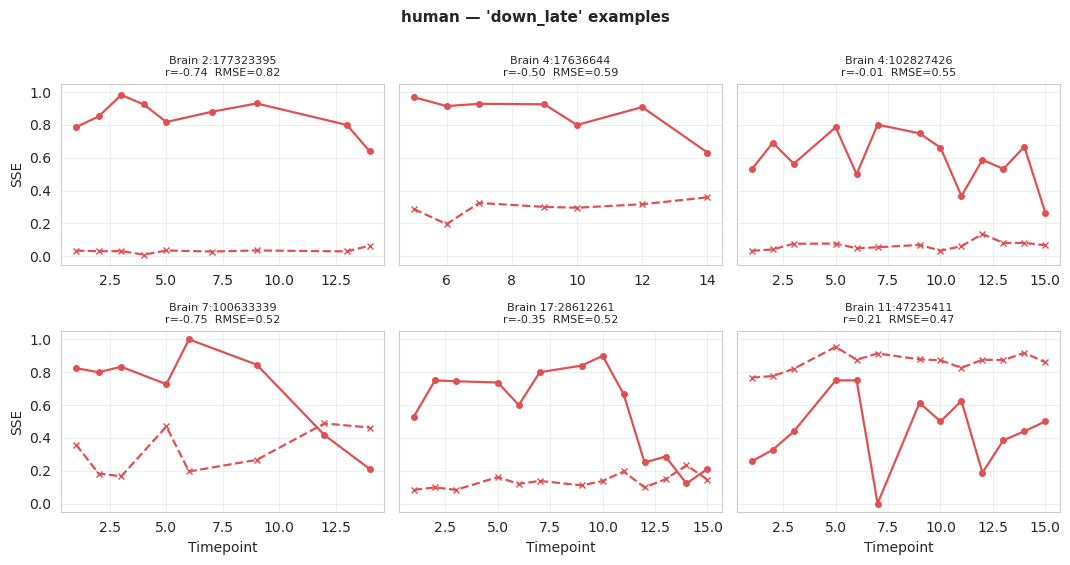

In [21]:
# Example: the worst-recovered sites of a shape (largest RMSE) — where the model fails
plot_examples("down_late", n=6, rank_by="mae", ascending=False)
plt.show()

### 4.5 Summary table

Median metrics per trajectory type, saved alongside the figures.

In [ ]:
summary = (
    traj[traj["n_obs_usage"] > 3]
    .groupby("ClusterShape")
    .agg(n_trajectories=("chr_pos", "size"),
         median_pearson_r=("pearson_r", "median"),
         mean_pearson_r=("pearson_r", "mean"),
         median_cosine=("cosine", "median"),
         median_rmse=("mae", "median"),
         mean_true_usage=("mean_true_usage", "mean"),
         mean_n_obs=("n_obs_usage", "mean"))
    .reindex(present)
    .round(3)
)
out_csv = os.path.join(OUT_DIR, "trajectory_type_metrics_summary.csv")
summary.to_csv(out_csv)
print(f"Saved -> {out_csv}")
summary

Saved -> /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/lora_32_human_mouse_rat_rabbit_opossum/preds_intersect_protein_coding/human/trajectory_types/trajectory_type_metrics_summary.csv


,n_trajectories,median_pearson_r,mean_pearson_r,median_cosine,median_rmse,mean_true_usage,mean_n_obs
ClusterShape,,,,,,,
up_early,18,0.042,0.026,0.962,0.267,0.686,8.000
up_late,30,-0.003,0.086,0.889,0.263,0.389,8.000
up_mid,36,-0.093,-0.022,0.981,0.231,0.668,8.528
down_early,9,-0.254,-0.108,0.988,0.196,0.791,6.778
down_late,215,0.539,0.418,0.990,0.149,0.795,10.028
up-down,66,0.146,0.150,0.983,0.218,0.687,8.364
down-up,177,0.427,0.348,0.990,0.154,0.809,9.220
flat_high,7195,0.125,0.123,0.998,0.100,0.946,9.894
flat_mid_high,483,0.199,0.155,0.985,0.193,0.726,9.176
